# `erode`
Erodes the foreground of a boolean image with a round structuring element of radius `r`.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.erode)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], r: int, dt: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]] = None, method: str = 'dt', smooth: bool = True)>

## `im`
A boolean image with the foreground (the phase to be eroded) marked as `True`. Both 2D and 3D images are supported.

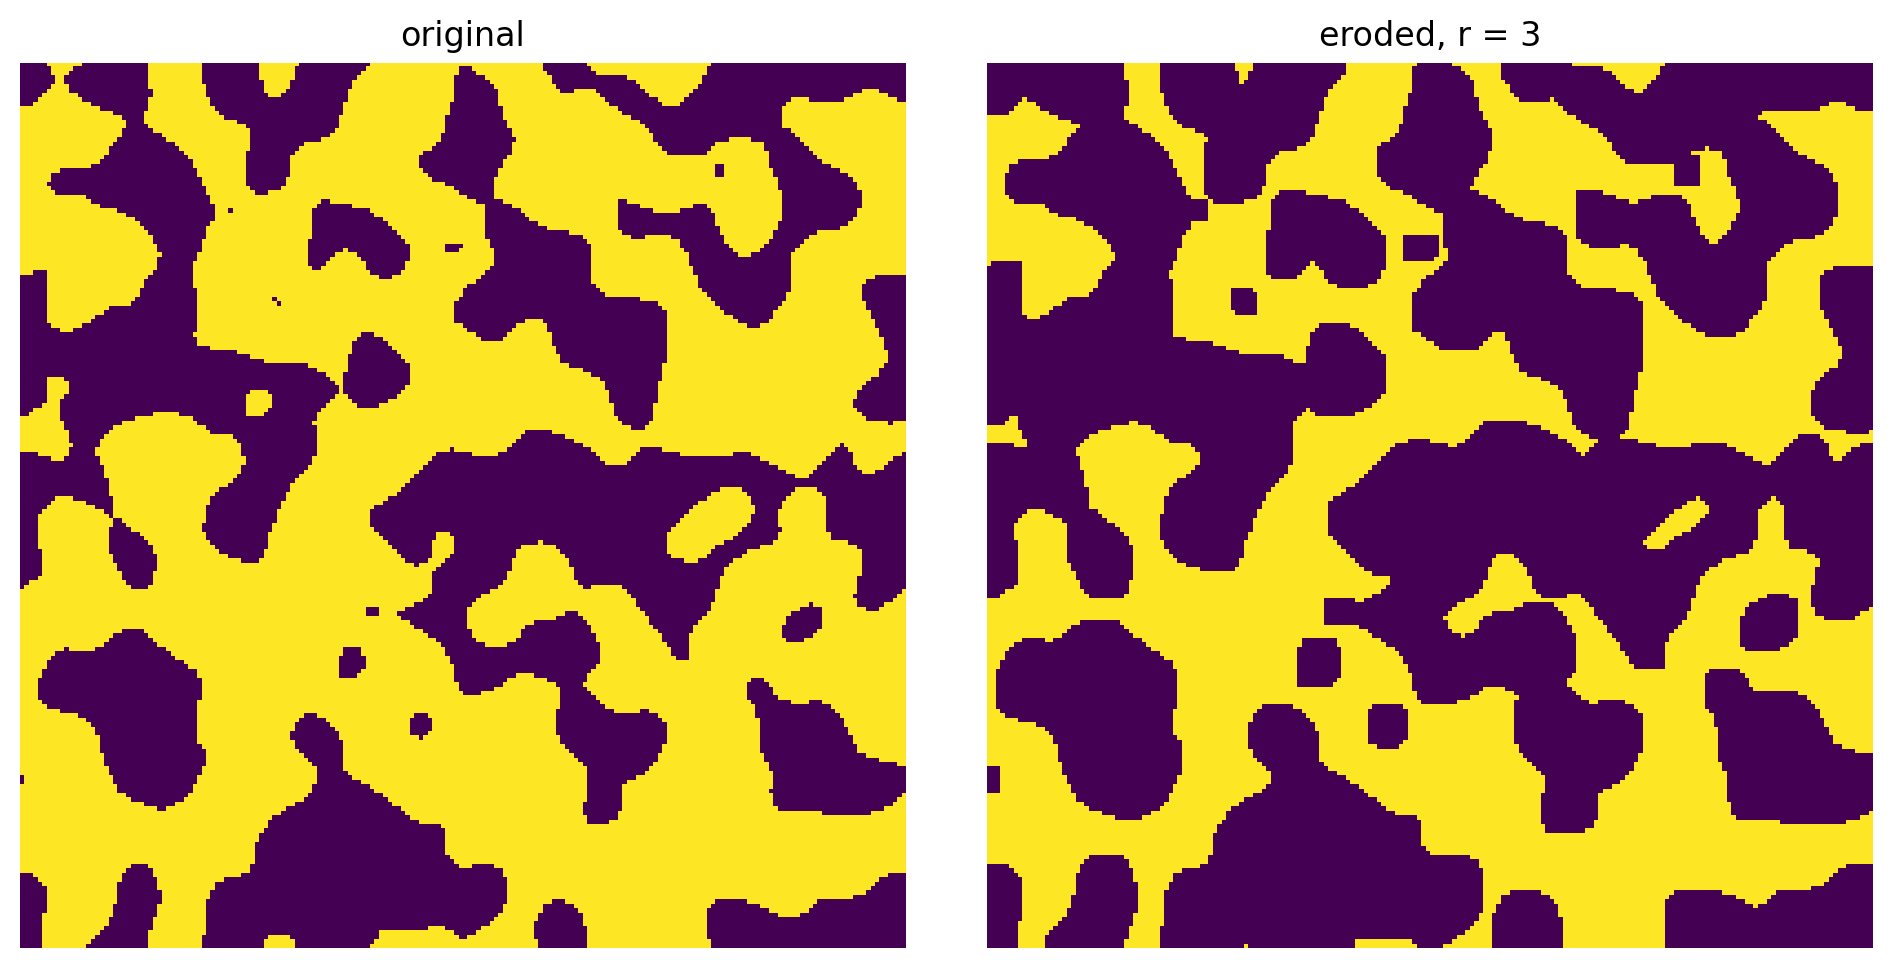

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.6, seed=0)
ero = ps.filters.erode(im=im, r=3)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(im, origin='lower', interpolation='none')
ax[0].set_title('original')
ax[0].axis(False)
ax[1].imshow(ero, origin='lower', interpolation='none')
ax[1].set_title('eroded, r = 3')
ax[1].axis(False);

## `r`
Radius of the round structuring element, in voxels. Larger values erode further.

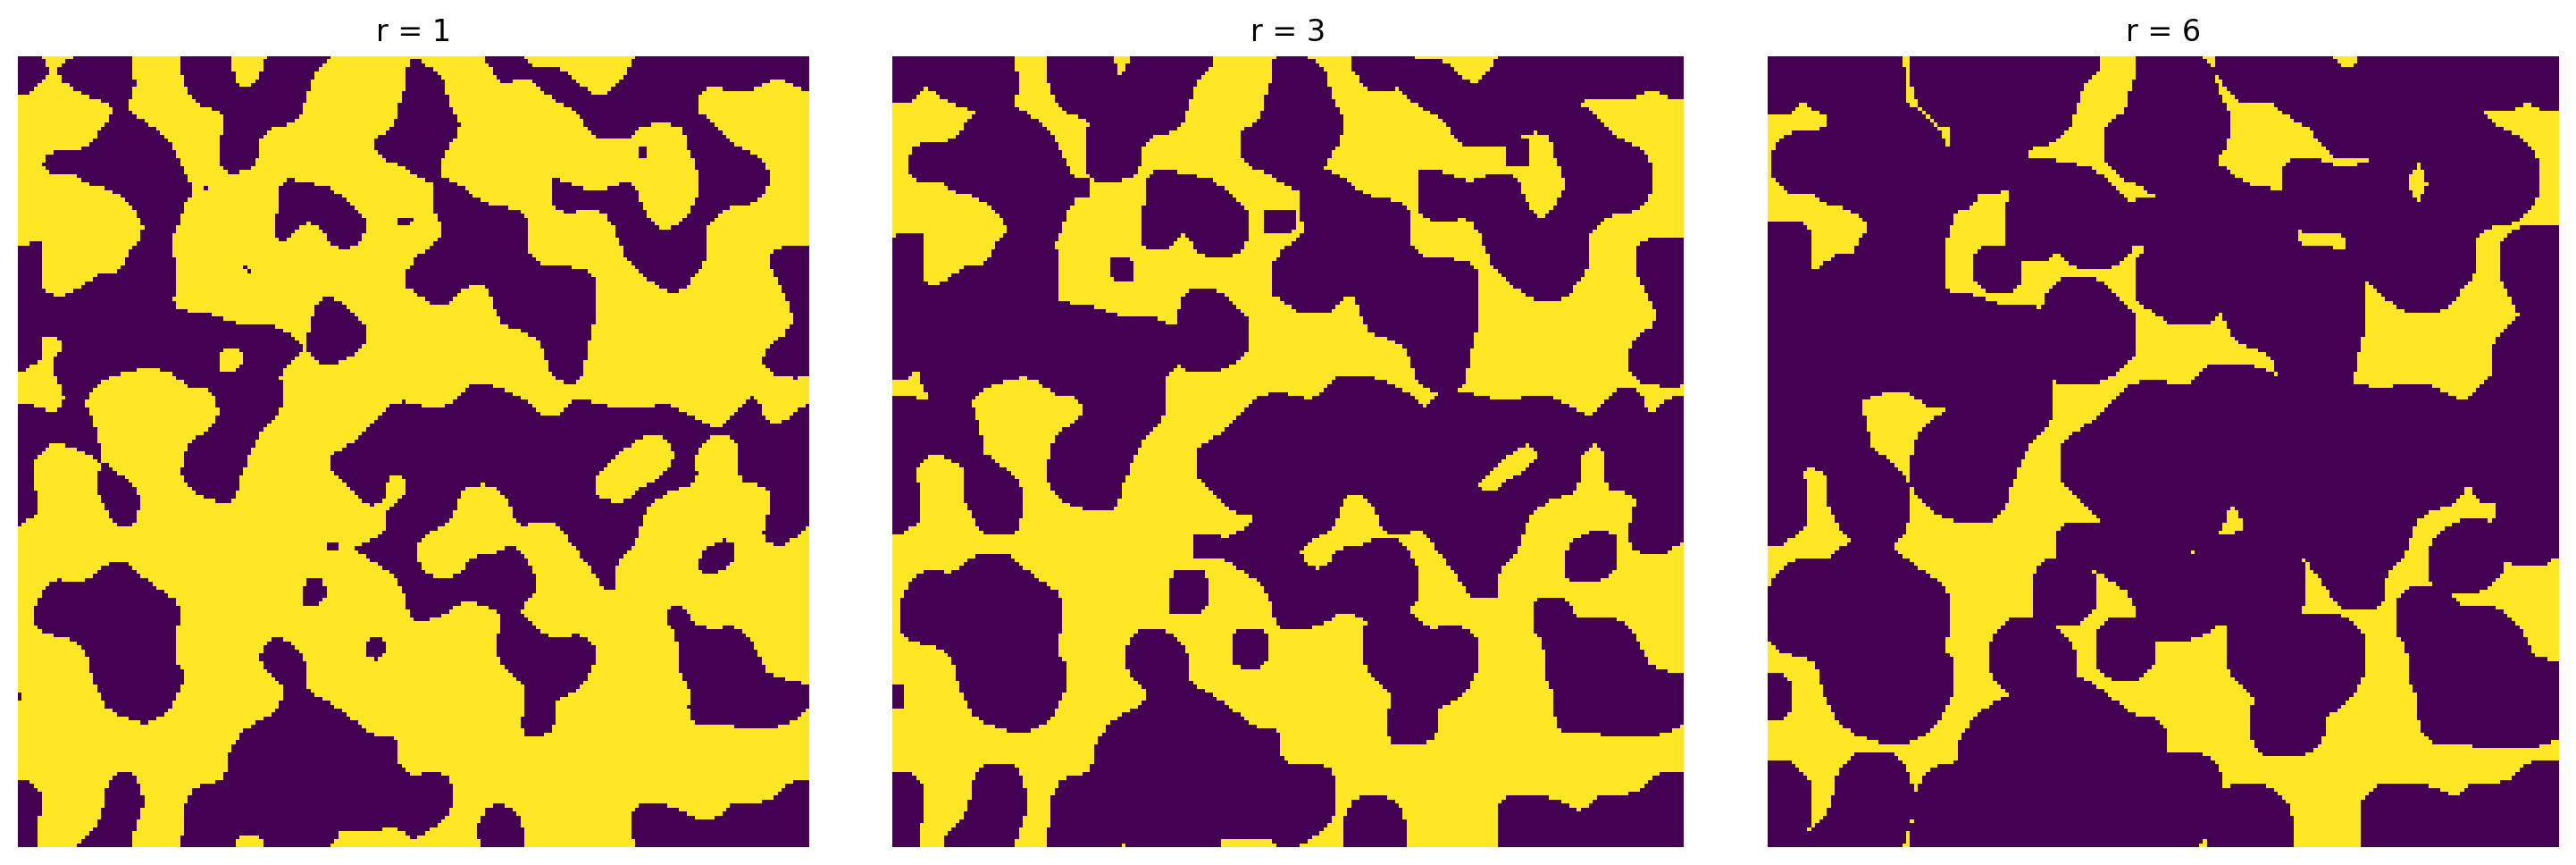

In [4]:
fig, ax = plt.subplots(1, 3, figsize=[15, 5])
for axis, r in zip(ax, [1, 3, 6]):
    ero = ps.filters.erode(im=im, r=r)
    axis.imshow(ero, origin='lower', interpolation='none')
    axis.set_title(f'r = {r}')
    axis.axis(False)

## `method`
Two equivalent implementations are available. `'dt'` (default) finds all voxels within `r` of the background using the distance transform of the *foreground* and removes them; `'conv'` finds them by FFT-based convolution against a round structuring element. Results are equivalent.

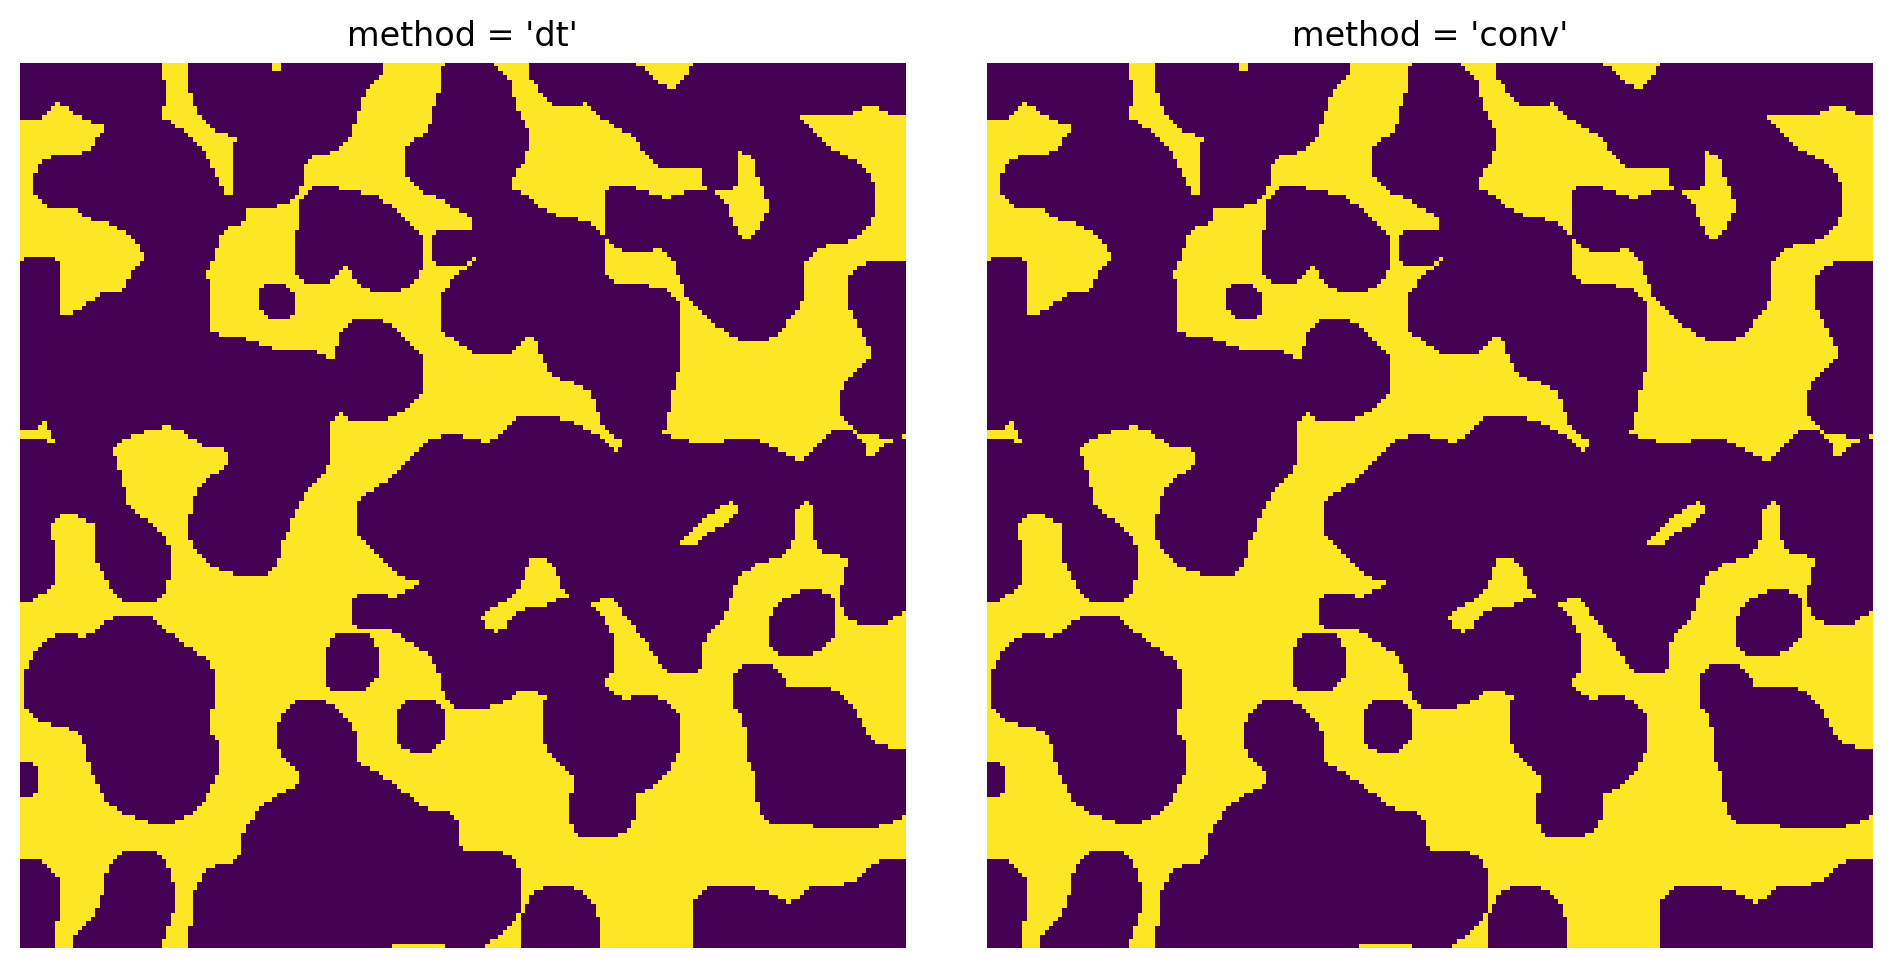

In [5]:
ero_dt = ps.filters.erode(im=im, r=4, method='dt')
ero_conv = ps.filters.erode(im=im, r=4, method='conv')

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(ero_dt, origin='lower', interpolation='none')
ax[0].set_title("method = 'dt'")
ax[0].axis(False)
ax[1].imshow(ero_conv, origin='lower', interpolation='none')
ax[1].set_title("method = 'conv'")
ax[1].axis(False);

## `smooth`
When `True` (default) a single-voxel protrusion on the face of the structuring element is removed. Set to `False` to keep the bare digital sphere.

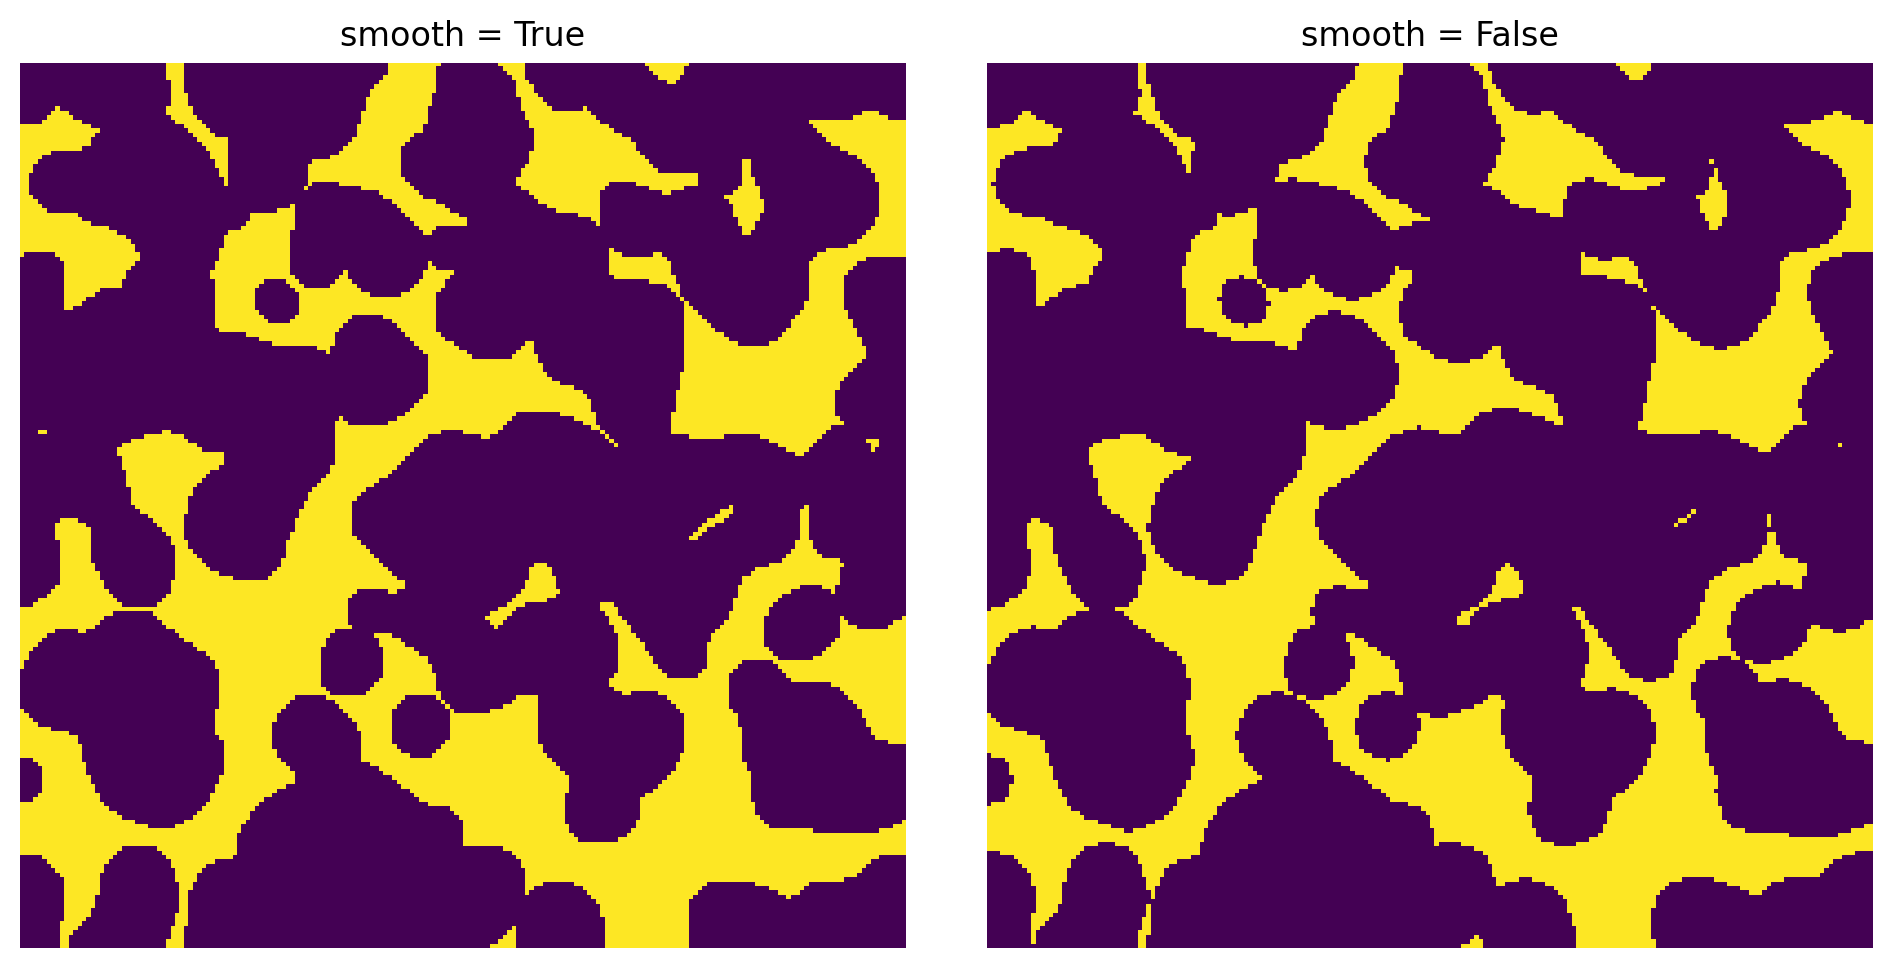

In [6]:
ero_smooth = ps.filters.erode(im=im, r=5, smooth=True)
ero_rough = ps.filters.erode(im=im, r=5, smooth=False)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(ero_smooth, origin='lower', interpolation='none')
ax[0].set_title('smooth = True')
ax[0].axis(False)
ax[1].imshow(ero_rough, origin='lower', interpolation='none')
ax[1].set_title('smooth = False')
ax[1].axis(False);

## `dt`
If the distance transform of the *foreground* is already available it can be passed in to avoid recomputing it. This argument only matters when `method='dt'`.

In [7]:
from porespy.tools import get_edt

dt = get_edt()(im)
ero = ps.filters.erode(im=im, r=4, dt=dt)